In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../dataset/apple_global_sales_dataset.csv")

df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,NaN,Starlight,159.27,7,1,148.12,148.12,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,NaN,Black,29.99,15,5,25.49,127.45,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,NaN,Titanium,293.92,0,4,293.92,1175.68,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,1 TB SSD,Starlight,1932.77,0,2,1932.77,3865.54,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,NaN,Midnight,755.44,5,3,717.67,2153.01,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

In [4]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   4804
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        8056
customer_rating           3360
return_status                0
dtype: int64

In [5]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,1.150000e+04,8140.000000
mean,2022.997304,807.851191,3.841565,2.023478,777.365478,1568.319065,1029.406647,1.464369e+06,4.000934
std,0.821747,1112.437595,4.783161,1.443599,1072.915122,2839.759822,4072.334957,9.941160e+06,0.575192
min,2022.000000,26.690000,0.000000,1.000000,22.730000,23.000000,0.790000,2.130000e+01,3.000000
25%,2022.000000,180.147500,0.000000,1.000000,178.297500,305.740000,0.920000,1.041693e+03,3.500000
50%,2023.000000,593.905000,2.000000,1.000000,573.420000,833.040000,7.240000,6.164160e+03,4.000000
75%,2024.000000,958.387500,7.000000,3.000000,928.567500,1748.360000,91.500000,7.471653e+04,4.500000
max,2024.000000,7551.010000,15.000000,8.000000,7551.010000,59529.520000,24500.000000,5.075175e+08,5.000000


# Cleaning Dataset

In [7]:
print(df[df['storage'].isnull()][['product_name', 'storage']].to_string(index=False))

            product_name storage
       AirPods (3rd Gen)     NaN
USB-C Woven Charge Cable     NaN
    Apple Watch Series 8     NaN
     Apple Watch Ultra 2     NaN
          Magic Keyboard     NaN
   Apple TV 4K (3rd Gen)     NaN
USB-C Woven Charge Cable     NaN
          Magic Keyboard     NaN
       AirPods (3rd Gen)     NaN
  Apple Pencil (2nd Gen)     NaN
             Magic Mouse     NaN
       AirPods (3rd Gen)     NaN
          Magic Keyboard     NaN
   AirPods Pro (2nd Gen)     NaN
USB-C Woven Charge Cable     NaN
   AirPods Pro (2nd Gen)     NaN
   AirPods Pro (2nd Gen)     NaN
         MagSafe Charger     NaN
          Magic Keyboard     NaN
   Apple TV 4K (3rd Gen)     NaN
Apple Watch SE (2nd Gen)     NaN
   Apple TV 4K (3rd Gen)     NaN
  Apple Pencil (1st Gen)     NaN
       AirPods (2nd Gen)     NaN
          Magic Trackpad     NaN
          Magic Keyboard     NaN
Apple Watch SE (2nd Gen)     NaN
             AirPods Max     NaN
   AirPods Pro (2nd Gen)     NaN
USB-C Wove

In [8]:
df['storage'] = df['storage'].fillna('Not Applicable')

df['storage'].isnull().sum()

np.int64(0)

In [9]:

df = df.drop(columns=['previous_device_os'])

In [10]:
df['customer_rating'] = df.groupby('category')['customer_rating'].transform(lambda x: x.fillna(x.median()))

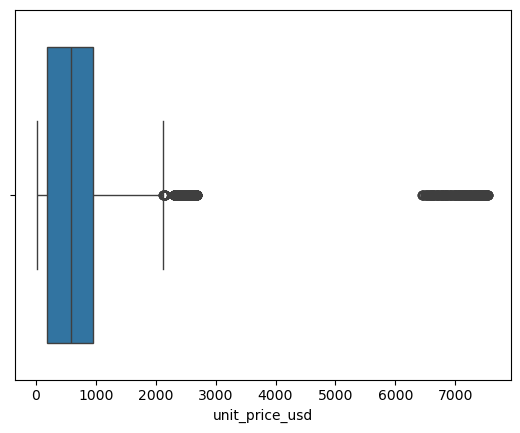

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['unit_price_usd'])
plt.show()

In [12]:
df.sort_values(by='unit_price_usd', ascending=False)[['product_name','unit_price_usd']].head(10)

,product_name,unit_price_usd
3732,Mac Pro (M2 Ultra),7551.01
3853,Mac Pro (M2 Ultra),7544.80
3220,Mac Pro (M2 Ultra),7543.20
5425,Mac Pro (M2 Ultra),7543.16
6279,Mac Pro (M2 Ultra),7542.15
10502,Mac Pro (M2 Ultra),7533.28
5095,Mac Pro (M2 Ultra),7532.45
4857,Mac Pro (M2 Ultra),7527.15
10800,Mac Pro (M2 Ultra),7526.24
1969,Mac Pro (M2 Ultra),7523.86


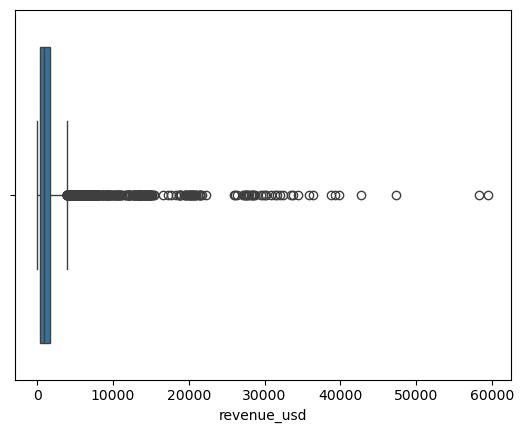

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['revenue_usd'])
plt.show()

In [14]:
df.sort_values(by='revenue_usd', ascending=False)[['product_name','units_sold','unit_price_usd','revenue_usd']].head(10)

,product_name,units_sold,unit_price_usd,revenue_usd
3730,Mac Pro (M2 Ultra),8,7441.19,59529.52
6106,Mac Pro (M2 Ultra),8,7285.55,58284.40
10526,Mac Pro (M2 Ultra),7,6893.36,47288.43
8318,Mac Pro (M2 Ultra),6,7500.32,42751.80
648,Mac Pro (M2 Ultra),6,6780.15,39867.30
7106,Mac Pro (M2 Ultra),6,6553.92,39323.52
5791,Mac Pro (M2 Ultra),6,7189.33,38822.40
7800,Mac Pro (M2 Ultra),5,7268.71,36343.55
6784,Mac Pro (M2 Ultra),5,7384.32,35813.95
1221,Mac Pro (M2 Ultra),5,7390.90,34367.70


In [15]:
print(df[df['country'] == 'Vietnam']['fx_rate_to_usd'].describe())

count      229.0
mean     24500.0
std          0.0
min      24500.0
25%      24500.0
50%      24500.0
75%      24500.0
max      24500.0
Name: fx_rate_to_usd, dtype: float64


# EDA

In [17]:
import pandas as pd

# Ambil hanya kolom numerik
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Hitung korelasi
correlation_matrix = numeric_df.corr()

correlation_matrix

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
year,1.000000,0.017683,-0.014136,0.008704,0.017541,0.008819,0.003457,0.011903,-0.005310
unit_price_usd,0.017683,1.000000,-0.010308,-0.003446,0.998301,0.755070,-0.010482,0.133406,0.001451
discount_pct,-0.014136,-0.010308,1.000000,-0.005998,-0.044947,-0.038354,-0.014628,-0.021520,0.012346
units_sold,0.008704,-0.003446,-0.005998,1.000000,-0.003011,0.384497,0.002207,0.083551,0.000526
discounted_price_usd,0.017541,0.998301,-0.044947,-0.003011,1.000000,0.757582,-0.009426,0.135874,0.000466
revenue_usd,0.008819,0.755070,-0.038354,0.384497,0.757582,1.000000,-0.012978,0.139827,0.001143
fx_rate_to_usd,0.003457,-0.010482,-0.014628,0.002207,-0.009426,-0.012978,1.000000,0.583349,-0.003618
revenue_local_currency,0.011903,0.133406,-0.021520,0.083551,0.135874,0.139827,0.583349,1.000000,-0.002161
customer_rating,-0.005310,0.001451,0.012346,0.000526,0.000466,0.001143,-0.003618,-0.002161,1.000000


In [18]:
df.groupby('product_name')['revenue_usd'].sum().sort_values(ascending=False)

product_name
Mac Pro (M2 Ultra)              3724222.55
MacBook Pro 16-inch (M3 Pro)    1491289.26
MacBook Pro 14-inch (M3)        1027383.82
MacBook Air 13-inch (M2)         634573.15
iMac 24-inch (M3)                624597.43
iPhone 13 Pro Max                605116.33
iPhone 15 Pro Max                597448.92
MacBook Air 15-inch (M2)         556390.06
iPad Pro 12.9-inch (M2)          538088.68
iPhone 14 Pro                    525599.32
iPhone 15 Pro                    509914.40
iPhone 13 Pro                    476574.66
iPhone 15 Plus                   448101.82
iPhone 14 Plus                   440069.66
iPhone 14                        438088.35
iPhone 14 Pro Max                436050.41
Apple Watch Ultra 2              434910.30
iPad Pro 11-inch (M2)            416016.23
iPhone 13                        361787.15
iPhone 15                        353607.33
iPhone 13 Mini                   339762.18
iPad Air (M1)                    316209.10
iPad Mini (6th Gen)              311794.0

In [20]:
df.groupby('product_name')['units_sold'].sum().sort_values(ascending=False)

product_name
Apple Watch SE (2nd Gen)        664
iPad Mini (6th Gen)             647
MacBook Pro 16-inch (M3 Pro)    620
iPhone 14 Pro                   608
AirPods Pro (2nd Gen)           603
MacBook Air 13-inch (M2)        598
iPhone 13 Mini                  590
MagSafe Charger                 579
iPhone 13 Pro Max               577
iPad (10th Generation)          576
iPhone 14                       565
Apple Watch Ultra 2             564
Apple TV 4K (3rd Gen)           559
iPhone 13 Pro                   552
iPad Air (M1)                   549
Apple Watch Series 9            549
Magic Mouse                     548
Mac mini (M2)                   547
AirPods Max                     547
Mac Pro (M2 Ultra)              546
iPad Pro 11-inch (M2)           543
AirPods (2nd Gen)               542
Magic Keyboard                  540
iPhone 13                       538
Magic Trackpad                  536
MacBook Pro 14-inch (M3)        536
USB-C Woven Charge Cable        535
iPhone 15 Pro  

In [21]:
df['product_name'].value_counts()

product_name
Apple Watch SE (2nd Gen)        312
iPad Mini (6th Gen)             303
MacBook Pro 16-inch (M3 Pro)    296
Apple Watch Series 9            290
Magic Trackpad                  282
MagSafe Charger                 280
MacBook Air 13-inch (M2)        280
iPhone 13 Pro Max               278
iPhone 13 Pro                   277
iPad Air (M1)                   276
iPhone 14 Pro                   276
iPhone 13 Mini                  275
Mac Pro (M2 Ultra)              275
iPhone 13                       275
AirPods Pro (2nd Gen)           275
iPhone 14                       275
iPad Pro 11-inch (M2)           273
iPad (10th Generation)          271
MacBook Pro 14-inch (M3)        270
AirPods Max                     270
Magic Keyboard                  270
AirPods (2nd Gen)               269
USB-C Woven Charge Cable        268
Apple Pencil (1st Gen)          267
Apple TV 4K (3rd Gen)           265
Apple Watch Ultra 2             264
iPhone 14 Pro Max               263
Mac mini (M2)  

In [22]:
df.groupby('category')['customer_rating'] \
.mean() \
.sort_values(ascending=False)

category
iPhone         4.006533
Accessories    4.003901
Mac            4.000747
Apple Watch    3.998046
AirPods        3.994826
iPad           3.986367
Name: customer_rating, dtype: float64

In [23]:
pd.crosstab(df['country'], df['category'])

category,Accessories,AirPods,Apple Watch,Mac,iPad,iPhone
country,,,,,,
Argentina,64,23,27,40,33,74
Australia,63,22,32,37,35,69
Austria,52,20,20,38,32,65
Bangladesh,55,17,20,39,34,69
Belgium,48,21,18,43,27,64
Brazil,61,22,29,39,31,64
Canada,67,28,21,51,33,65
Chile,56,25,22,24,29,83
China,51,25,21,31,27,75


In [24]:
country_pref = pd.crosstab(
    df['country'],
    df['category'],
    normalize='index'
) * 100

country_pref

category,Accessories,AirPods,Apple Watch,Mac,iPad,iPhone
country,,,,,,
Argentina,24.521073,8.812261,10.344828,15.325670,12.643678,28.352490
Australia,24.418605,8.527132,12.403101,14.341085,13.565891,26.744186
Austria,22.907489,8.810573,8.810573,16.740088,14.096916,28.634361
Bangladesh,23.504274,7.264957,8.547009,16.666667,14.529915,29.487179
Belgium,21.719457,9.502262,8.144796,19.457014,12.217195,28.959276
Brazil,24.796748,8.943089,11.788618,15.853659,12.601626,26.016260
Canada,25.283019,10.566038,7.924528,19.245283,12.452830,24.528302
Chile,23.430962,10.460251,9.205021,10.041841,12.133891,34.728033
China,22.173913,10.869565,9.130435,13.478261,11.739130,32.608696


In [29]:
country_pref.idxmax(axis=1)

country
Argentina              iPhone
Australia              iPhone
Austria                iPhone
Bangladesh             iPhone
Belgium                iPhone
Brazil                 iPhone
Canada            Accessories
Chile                  iPhone
China                  iPhone
Colombia               iPhone
Denmark                iPhone
Egypt                  iPhone
Finland                iPhone
France                 iPhone
Germany                iPhone
Hong Kong              iPhone
India                  iPhone
Indonesia              iPhone
Ireland                iPhone
Italy                  iPhone
Japan                  iPhone
Kenya                  iPhone
Malaysia               iPhone
Mexico                 iPhone
Netherlands            iPhone
New Zealand            iPhone
Nigeria                iPhone
Norway                 iPhone
Pakistan               iPhone
Philippines            iPhone
Poland                 iPhone
Portugal               iPhone
Russia                 iPhone
Sa

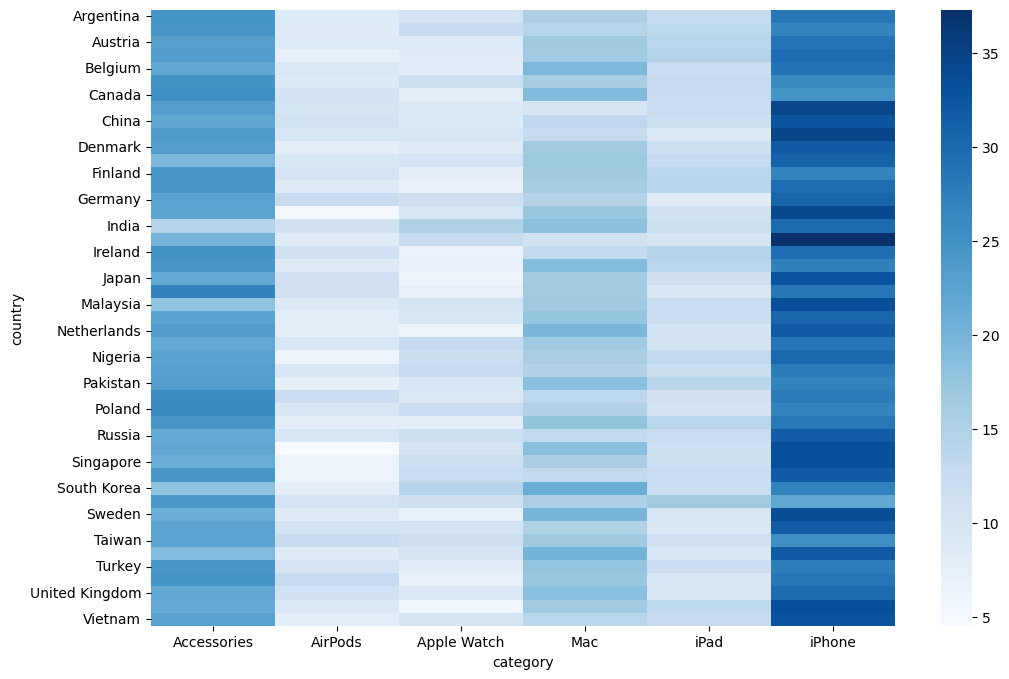

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    country_pref,
    cmap='Blues'
)

plt.show()

In [ ]:
# df.to_csv("apple_sales_cleaned.csv", index=False)